In [1]:
import pandas as pd
import numpy as np
from numpy import transpose as T
import glob
import os
import cartopy
import cartopy.crs as ccrs
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import geopandas as gpd
from scipy.optimize import curve_fit
from netCDF4 import Dataset
import scipy
from scipy import stats
from scipy.ndimage import distance_transform_edt
from datetime import datetime,timedelta
from numpy import genfromtxt as gftxt
import regionmask
from pyproj import Transformer
from datetime import datetime,timedelta
import sys
from pathlib import Path

In [2]:
sys.path.append(str(Path.cwd().parents[1]))
from utils.grid_map_functions import(land_masking, defining_grids)

map_projection = ccrs.NorthPolarStereo()

x_grid_edge_25,y_grid_edge_25,new_x_edge_25,new_y_edge_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'edge')
x_grid_centre_25,y_grid_centre_25,new_x_centre_25,new_y_centre_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'centre')
land_mask_25 = land_masking(new_x_centre_25,new_y_centre_25,map_projection)

transformer = Transformer.from_crs(map_projection, "EPSG:4326", always_xy=True)
lon0, lat0 = transformer.transform(new_x_centre_25.ravel(), new_y_centre_25.ravel())
lon1 = lon0.reshape(new_x_centre_25.shape)
lat1 = lat0.reshape(new_y_centre_25.shape)

from utils.stats_functions import(absdiff,corr,rmsd)

base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

In [3]:
def add_land_buffer_distance(land_mask, grid_spacing_km, buffer_km):
    """
    Create buffer based on real distance (km)
    """
    # दूरी from land: compute distance from NON-land
    distance = distance_transform_edt(~land_mask) * grid_spacing_km
    
    # mask where within buffer distance
    buffer_mask = distance <= buffer_km
    
    return land_mask | buffer_mask

def retrieving_fractions(input_folder,yrs):
    fractions = {}
    for array in input_folder:
        fraction0 = np.load(array)
        fraction = np.where(land_mask_buffered, np.nan, fraction0)
        fname = os.path.basename(array)
        date = fname.split('_')[0]
        year = str(date[0:4])
        month = str(date[4:6])
        if year in yrs:
            if year == '2018' and int(month) < 10:# don't include jan - apr for 2018
                continue
            if year == '2025' and int(month) > 4: # don't include oct - dec for 2025
                continue
            fractions[date] = fraction
    return(fractions)

land_mask_buffered = add_land_buffer_distance(land_mask_25,grid_spacing_km=25,buffer_km=5)


# Datasets

## Compared to MODIS (Monthly)

### Ku

In [51]:
s3_cs2_merged_monthly_leads = pd.read_csv(f'{base_dir}Monthly_Averages/S3_CS2_Merged_Lead_Fraction_Averages.csv')
s3_cs2_merged_monthly_leads['Datetime'] = pd.to_datetime(s3_cs2_merged_monthly_leads['Month'],
    format='%Y%m')

modis_monthly_avg_leads = pd.read_csv(f'{base_dir}MODIS_LeadFraction/MODIS_Monthly_Average_LFA_AllYears.csv')
modis_monthly_avg_leads['Datetime'] = pd.to_datetime(modis_monthly_avg_leads['Datetime'],
    format='%Y-%m-%d')
modis_monthly_avg_leads_mg = modis_monthly_avg_leads.rename(columns={c:c+'_MODIS' for c in modis_monthly_avg_leads.columns if c not in ['Datetime']})

modis_s3_cs2_merged_monthly_leads = s3_cs2_merged_monthly_leads.merge(modis_monthly_avg_leads_mg, 
                                                              on='Datetime', how='inner', suffixes=(' S3 CS2 Merged', ' MODIS'))
modis_s3_cs2_merged_monthly_leads = modis_s3_cs2_merged_monthly_leads.drop(['StartDate_MODIS','EndDate_MODIS','Date_MODIS','Month'],axis=1)
modis_s3_cs2_merged_monthly_leads = modis_s3_cs2_merged_monthly_leads.rename(columns={'Lead Density (%)_MODIS':'MODIS Lead Density'})

### Merged

In [50]:
merged_monthly_leads = pd.read_csv(f'{base_dir}Monthly_Averages/Merged_Lead_Fraction_Averages.csv')
merged_monthly_leads['Datetime'] = pd.to_datetime(merged_monthly_leads['Month'],
    format='%Y%m')

modis_monthly_avg_leads = pd.read_csv(f'{base_dir}MODIS_LeadFraction/MODIS_Monthly_Average_LFA_AllYears.csv')
modis_monthly_avg_leads['Datetime'] = pd.to_datetime(modis_monthly_avg_leads['Datetime'],
    format='%Y-%m-%d')
modis_monthly_avg_leads_mg = modis_monthly_avg_leads.rename(columns={c:c+'_MODIS' for c in modis_monthly_avg_leads.columns if c not in ['Datetime']})

modis_merged_monthly_leads = merged_monthly_leads.merge(modis_monthly_avg_leads_mg, 
                                                              on='Datetime', how='inner', suffixes=(' Merged', ' MODIS'))
modis_merged_monthly_leads = modis_merged_monthly_leads.drop(['StartDate_MODIS','EndDate_MODIS','Date_MODIS','Month'],axis=1)
modis_merged_monthly_leads = modis_merged_monthly_leads.rename(columns={'Lead Density (%)_MODIS':'MODIS Lead Density'})

## Compared to MODIS (Weekly)

### MODIS

In [23]:
modis_7day_leads = sorted(glob.glob(f'{base_dir}MODIS_LeadFraction/Weekly_Averages_25km_Grid/*_MODIS_Weekly_Average_LFA.npy'))

weekly_modis_leads = {}
weekly_average_modis_leads = []

for lead_file in modis_7day_leads[:]:
    lead_data0 = np.load(lead_file)
    lead_data = np.where(land_mask_buffered, np.nan, lead_data0)
    
    filename = os.path.basename(lead_file)
    date_key = filename.split('_MODIS')[0]

    weekly_modis_leads[date_key] = lead_data

    start_date = date_key[0:8]
    
    avg_lead_data = np.nanmean(lead_data)
    weekly_average_modis_leads.append({'Date':date_key,'Lead Density (%)':avg_lead_data,
                                       'StartDate':start_date})
    
weekly_average_modis_leads_df = pd.DataFrame(weekly_average_modis_leads)
weekly_average_modis_leads_df['Datetime'] = pd.to_datetime(weekly_average_modis_leads_df['StartDate'],
    format='%Y%m%d')


### Merged

In [24]:
# Comparison to Merged Dataset
merged_7day_leads = sorted(glob.glob(base_dir+'SevenDay_Averages/25km/Merged/*_Merged_Lead_Density.npy'))

weekly_merged_leads = {}
weekly_average_merged_leads = []

for lead_file in merged_7day_leads[:]:
    lead_data0 = np.load(lead_file)
    lead_data = np.where(land_mask_buffered, np.nan, lead_data0)
    
    filename = os.path.basename(lead_file)
    date_key = filename.split('_SevenDay')[0]

    weekly_merged_leads[date_key] = lead_data

    start_date = date_key[0:8]

    avg_lead_data = np.nanmean(lead_data)
    weekly_average_merged_leads.append({'Date':date_key,'Lead Density (%)':avg_lead_data,
                                       'StartDate':start_date})
    
weekly_average_merged_leads_df = pd.DataFrame(weekly_average_merged_leads)
weekly_average_merged_leads_df['Datetime'] = pd.to_datetime(weekly_average_merged_leads_df['StartDate'],
    format='%Y%m%d')

### Ku

In [25]:
# Comparison to Merged Dataset
ku_7day_leads = sorted(glob.glob(base_dir+'SevenDay_Averages/25km/S3_CS2_Merged/*_Merged_Lead_Density.npy'))

weekly_ku_leads = {}
weekly_average_ku_leads = []

for lead_file in ku_7day_leads[:]:
    lead_data0 = np.load(lead_file)
    lead_data = np.where(land_mask_buffered, np.nan, lead_data0)
    
    filename = os.path.basename(lead_file)
    date_key = filename.split('_SevenDay')[0]

    weekly_ku_leads[date_key] = lead_data

    start_date = date_key[0:8]

    avg_lead_data = np.nanmean(lead_data)
    weekly_average_ku_leads.append({'Date':date_key,'Lead Density (%)':avg_lead_data,
                                       'StartDate':start_date})
    
weekly_average_ku_leads_df = pd.DataFrame(weekly_average_ku_leads)
weekly_average_ku_leads_df['Datetime'] = pd.to_datetime(weekly_average_ku_leads_df['StartDate'],
    format='%Y%m%d')

In [38]:
weekly_average_modis_leads_df0 = weekly_average_modis_leads_df.rename(columns={'Lead Density (%)': 'MODIS Lead Density'})
weekly_average_merged_leads_df0 = weekly_average_merged_leads_df.rename(columns={'Lead Density (%)': 'Merged Lead Density'})
weekly_average_ku_leads_df0 = weekly_average_ku_leads_df.rename(columns={'Lead Density (%)': 'Ku Lead Density'})

leads_weekly_all_df = (weekly_average_modis_leads_df0[['Datetime','MODIS Lead Density']]
                          .merge(weekly_average_merged_leads_df0[['Datetime','Merged Lead Density']],
                          on='Datetime',how='inner')
                          .merge(weekly_average_ku_leads_df0[['Datetime','Ku Lead Density']],
                          on='Datetime',how='inner'))


## LS8 Comparison

In [10]:
ls8_evaluation_summary = pd.read_excel(f'{base_dir}LS8/LS8_Evaluation.xlsx', dtype={'Idt': str})
ls8_files = ls8_evaluation_summary['LS8 File']
ls8_evaluation_summary['Datetimes'] = pd.to_datetime(ls8_evaluation_summary['Date'].astype(str),format="%Y%m%d")

grid_input_dir = (f'{base_dir}LS8/TenDay_Densities_Cropped/')

array_statistics,mean_statistics = [],[]

for date, str_date,idt in zip(ls8_evaluation_summary['Datetimes'][:],
                          ls8_evaluation_summary['Date'][:],ls8_evaluation_summary['Idt'][:]):
    
    year = str(str_date)[:4]
    ls8_leads = np.load(f'{grid_input_dir}LS8/{str_date}_{idt}_LS8_Lead_Density.npy')
    cs2_leads = np.load(f'{grid_input_dir}CS2/{str_date}_{idt}_CS2_LS8Cropped_Lead_Density.npy')
    s3_leads = np.load(f'{grid_input_dir}S3/{str_date}_{idt}_S3_LS8Cropped_Lead_Density.npy')
    is2_leads = np.load(f'{grid_input_dir}IS2/{str_date}_{idt}_IS2_LS8Cropped_Lead_Density.npy')
    merged_leads = np.load(f'{grid_input_dir}Merged/{str_date}_{idt}_Merged_LS8Cropped_Lead_Density.npy')
    ku_leads = np.load(f'{grid_input_dir}Ku/{str_date}_{idt}_Ku_LS8Cropped_Lead_Density.npy')

    # Means 
    mean_cs2 = np.nanmean(cs2_leads)
    mean_is2 = np.nanmean(is2_leads)
    mean_ls8 = np.nanmean(ls8_leads)
    mean_s3 = np.nanmean(s3_leads)
    mean_merged = np.nanmean(merged_leads)
    mean_ku = np.nanmean(ku_leads)

    mean_statistics.append([str_date,idt,mean_cs2,mean_is2,mean_s3,mean_merged,mean_ku,mean_ls8])


mean_statistics_df = pd.DataFrame(mean_statistics, columns=['Date','Idt',
    'CS2','IS2','S3','Merged','Ku','LS8'])

/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_57756/1019860341.py:24: RuntimeWarning: Mean of empty slice
  mean_s3 = np.nanmean(s3_leads)


# Plotting 

## With Weekly MODIS

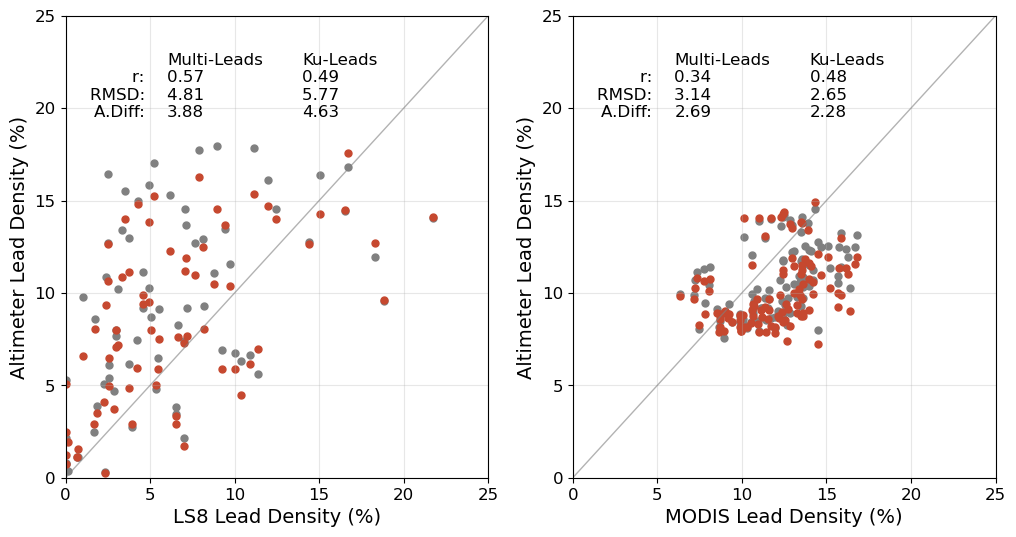

In [49]:
cs2_lead_colour = '#2D74BE'
s3_lead_colour = '#489963'
is2_lead_colour = '#733498'
merged_lead_colour = '#C6482F'
modis_lead_colour = '#F0CF65'
s3_cs2_merged_lead_colour = 'grey'

fig, ax = plt.subplots(1,2,figsize=(12, 6))

ax[0].scatter(mean_statistics_df['LS8'],mean_statistics_df['Ku'],
              color=s3_cs2_merged_lead_colour, marker='o', s=25,label='Ku')
ax[0].scatter(mean_statistics_df['LS8'],mean_statistics_df['Merged'],
              color=merged_lead_colour, marker='o', s=25,label='Merged')

ax[1].scatter(leads_weekly_all_df['MODIS Lead Density'],
              leads_weekly_all_df['Ku Lead Density'],
              color=s3_cs2_merged_lead_colour, marker='o', s=25,label='Ku')

ax[1].scatter(leads_weekly_all_df['MODIS Lead Density'],
              leads_weekly_all_df['Merged Lead Density'],
              color=merged_lead_colour, marker='o', s=25,label='Merged')

for a in ax.flatten():
    a.xaxis.grid(True, 'major', alpha=0.3)
    a.yaxis.grid(True, 'major', alpha=0.3)
    a.tick_params(axis='both', labelsize=12)
    a.set_xlim([0,25])
    a.set_ylim([0,25])
    a.yaxis.set_major_locator(MultipleLocator(5))
    a.xaxis.set_major_locator(MultipleLocator(5))
    a.axline((0, 0), (30, 30), linestyle='-', color='grey', alpha=0.6,linewidth=1)

# LS8 Stats
ax[0].text(5,23,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[0].text(6,23,f"Multi-Leads\n"
           f"{corr(mean_statistics_df['LS8'],mean_statistics_df['Merged']):.2f} \n"
           f"{rmsd(mean_statistics_df['LS8'],mean_statistics_df['Merged']):.2f} \n"
           f"{absdiff(mean_statistics_df['LS8'],mean_statistics_df['Merged']):.2f}",
           fontsize=12,verticalalignment='top',horizontalalignment='left')
ax[0].text(14,23,f"Ku-Leads\n"
           f"{corr(mean_statistics_df['LS8'],mean_statistics_df['Ku']):.2f} \n"
           f"{rmsd(mean_statistics_df['LS8'],mean_statistics_df['Ku']):.2f} \n"
           f"{absdiff(mean_statistics_df['LS8'],mean_statistics_df['Ku']):.2f}",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

# MODIS Stats
ax[1].text(5,23,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[1].text(6,23,f"Multi-Leads\n"
           f"{corr(leads_weekly_all_df['MODIS Lead Density'],leads_weekly_all_df['Merged Lead Density']):.2f} \n"
           f"{rmsd(leads_weekly_all_df['MODIS Lead Density'],leads_weekly_all_df['Merged Lead Density']):.2f} \n"
           f"{absdiff(leads_weekly_all_df['MODIS Lead Density'],leads_weekly_all_df['Merged Lead Density']):.2f}",
           fontsize=12,verticalalignment='top',horizontalalignment='left')
ax[1].text(14,23,f"Ku-Leads\n"
           f"{corr(leads_weekly_all_df['MODIS Lead Density'],leads_weekly_all_df['Ku Lead Density']):.2f} \n"
           f"{rmsd(leads_weekly_all_df['MODIS Lead Density'],leads_weekly_all_df['Ku Lead Density']):.2f} \n"
           f"{absdiff(leads_weekly_all_df['MODIS Lead Density'],leads_weekly_all_df['Ku Lead Density']):.2f}",
           fontsize=12,verticalalignment='top',horizontalalignment='left')


ax[0].set_xlabel('LS8 Lead Density (%)',fontsize=14)
ax[0].set_ylabel('Altimeter Lead Density (%)',fontsize=14)

ax[1].set_xlabel('MODIS Lead Density (%)',fontsize=14)
ax[1].set_ylabel('Altimeter Lead Density (%)',fontsize=14)


plt.show()

#fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/Fig3.png',dpi=300,bbox_inches="tight")

## With Monthly MODIS

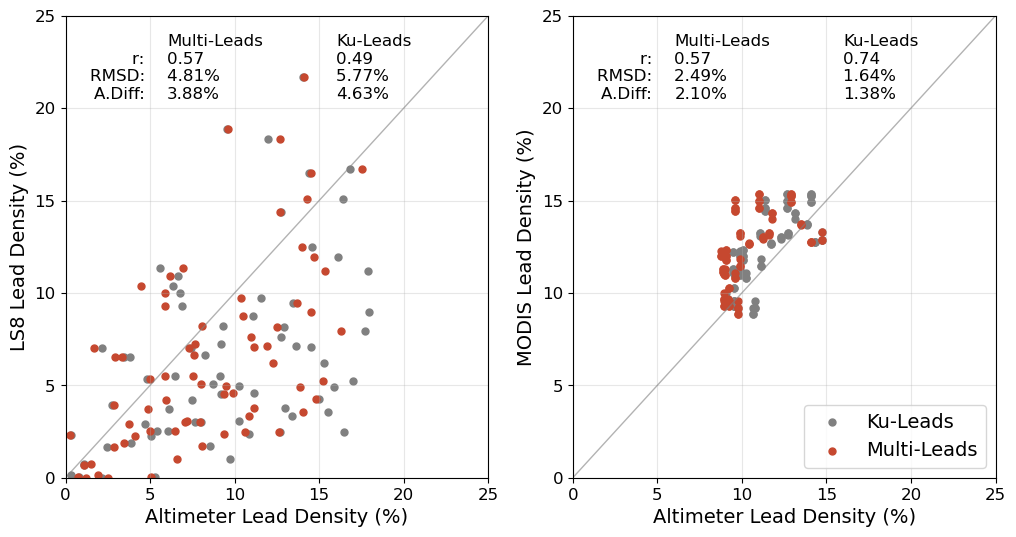

In [64]:
cs2_lead_colour = '#2D74BE'
s3_lead_colour = '#489963'
is2_lead_colour = '#733498'
merged_lead_colour = '#C6482F'
modis_lead_colour = '#F0CF65'
s3_cs2_merged_lead_colour = 'grey'

fig, ax = plt.subplots(1,2,figsize=(12, 6))

ax[0].scatter(mean_statistics_df['Ku'],mean_statistics_df['LS8'],
              color=s3_cs2_merged_lead_colour, marker='o', s=25,label='Ku')
ax[0].scatter(mean_statistics_df['Merged'],mean_statistics_df['LS8'],
              color=merged_lead_colour, marker='o', s=25,label='Merged')

ax[1].scatter(modis_s3_cs2_merged_monthly_leads['Merged'],
              modis_s3_cs2_merged_monthly_leads['MODIS Lead Density'],
              color=s3_cs2_merged_lead_colour, marker='o', s=25,label='Ku-Leads')

ax[1].scatter(modis_merged_monthly_leads['Merged'],
              modis_merged_monthly_leads['MODIS Lead Density'],
              color=merged_lead_colour, marker='o', s=25,label='Multi-Leads')

for a in ax.flatten():
    a.xaxis.grid(True, 'major', alpha=0.3)
    a.yaxis.grid(True, 'major', alpha=0.3)
    a.tick_params(axis='both', labelsize=12)
    a.set_xlim([0,25])
    a.set_ylim([0,25])
    a.yaxis.set_major_locator(MultipleLocator(5))
    a.xaxis.set_major_locator(MultipleLocator(5))
    a.axline((0, 0), (30, 30), linestyle='-', color='grey', alpha=0.6,linewidth=1)

# LS8 Stats
ax[0].text(5,24,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[0].text(6,24,f"Multi-Leads\n"
           f"{corr(mean_statistics_df['LS8'],mean_statistics_df['Merged']):.2f} \n"
           f"{rmsd(mean_statistics_df['LS8'],mean_statistics_df['Merged']):.2f}% \n"
           f"{absdiff(mean_statistics_df['LS8'],mean_statistics_df['Merged']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')
ax[0].text(16,24,f"Ku-Leads\n"
           f"{corr(mean_statistics_df['LS8'],mean_statistics_df['Ku']):.2f} \n"
           f"{rmsd(mean_statistics_df['LS8'],mean_statistics_df['Ku']):.2f}% \n"
           f"{absdiff(mean_statistics_df['LS8'],mean_statistics_df['Ku']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

# MODIS Stats
ax[1].text(5,24,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[1].text(6,24,f"Multi-Leads\n"
           f"{corr(modis_merged_monthly_leads['MODIS Lead Density'],modis_merged_monthly_leads['Merged']):.2f} \n"
           f"{rmsd(modis_merged_monthly_leads['MODIS Lead Density'],modis_merged_monthly_leads['Merged']):.2f}% \n"
           f"{absdiff(modis_merged_monthly_leads['MODIS Lead Density'],modis_merged_monthly_leads['Merged']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')
ax[1].text(16,24,f"Ku-Leads\n"
           f"{corr(modis_s3_cs2_merged_monthly_leads['MODIS Lead Density'],modis_s3_cs2_merged_monthly_leads['Merged']):.2f} \n"
           f"{rmsd(modis_s3_cs2_merged_monthly_leads['MODIS Lead Density'],modis_s3_cs2_merged_monthly_leads['Merged']):.2f}% \n"
           f"{absdiff(modis_s3_cs2_merged_monthly_leads['MODIS Lead Density'],modis_s3_cs2_merged_monthly_leads['Merged']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')


ax[0].set_xlabel('Altimeter Lead Density (%)',fontsize=14)
ax[0].set_ylabel('LS8 Lead Density (%)',fontsize=14)

ax[1].set_xlabel('Altimeter Lead Density (%)',fontsize=14)
ax[1].set_ylabel('MODIS Lead Density (%)',fontsize=14)


ax[1].legend(loc='lower right',fontsize=14,frameon=True)

plt.show()

fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/Fig6.png',dpi=300,bbox_inches="tight")